##  ASSIGNMENT NLP – 4
# Fine-Tuning BERT on IMDB Movie Reviews Dataset

## Import Libraries

In [9]:
!pip install transformers datasets torch scikit-learn pandas
import sys
!{sys.executable} -m pip install seaborn
import sys
!{sys.executable} -m pip install scikit-learn torch


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\rutur\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\rutur\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
import numpy as np
import torch
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer

## Load Dataset 

In [11]:
df = pd.read_csv("C:/Users/rutur/Downloads/IMDB Dataset.csv/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [12]:
df = df.sample(500, random_state=42)

In [13]:
print(len(df))

500


## Data Preprocessing

In [14]:
# Check missing values
df.isnull().sum()

# Convert sentiment to numeric
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

# Text cleaning function
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    return text

df['review'] = df['review'].apply(clean_text)

## Train-Test Split

In [15]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['review'],
    df['sentiment'],
    test_size=0.2,
    random_state=42
)

## Tokenization

In [16]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=32
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=32
)

## Create Dataset Class

In [17]:
class IMDbDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [18]:
train_dataset = IMDbDataset(train_encodings, train_labels)
test_dataset = IMDbDataset(test_encodings, test_labels)

## Load BERT Model

In [19]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights: 100%|█████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 2792.21it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were 

## Training Arguments

In [20]:

!pip install -U transformers accelerate torch

In [21]:
import sys
!{sys.executable} -m pip install accelerate


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\rutur\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [22]:
import sys
!{sys.executable} -m pip install accelerate transformers torch


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\rutur\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [23]:
import accelerate
import transformers
import torch

print(accelerate.__version__)
print(transformers.__version__)
print(torch.__version__)

1.13.0
5.8.0
2.11.0+cpu


In [24]:
from transformers import Trainer, TrainingArguments

In [25]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=1,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    learning_rate=2e-5
)

## Trainer

In [26]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights: 100%|█████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 3031.04it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were 

In [27]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

## Train Model

In [28]:
trainer.train()

C:\Users\rutur\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.19s/it]


TrainOutput(global_step=200, training_loss=0.6673809814453125, metrics={'train_runtime': 187.736, 'train_samples_per_second': 2.131, 'train_steps_per_second': 1.065, 'total_flos': 6577776384000.0, 'train_loss': 0.6673809814453125, 'epoch': 1.0})

## Predictions

In [29]:
predictions = trainer.predict(test_dataset)

preds = np.argmax(predictions.predictions, axis=1)

C:\Users\rutur\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


## Evaluation Metrics

In [31]:
accuracy = accuracy_score(test_labels, preds)
precision = precision_score(test_labels, preds)
recall = recall_score(test_labels, preds)
f1 = f1_score(test_labels, preds)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.56
Precision: 0.5454545454545454
Recall: 0.72
F1 Score: 0.6206896551724138


## Confusion Matrix

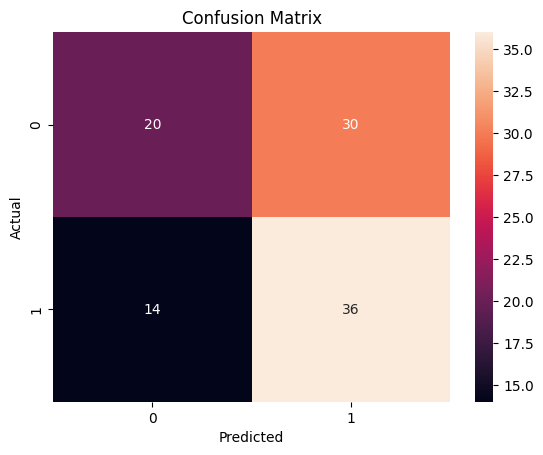

In [32]:
cm = confusion_matrix(test_labels, preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Experiments Section
Experiment 1 — Freeze BERT Layers

In [33]:
for param in model.bert.parameters():
    param.requires_grad = False

In [35]:
trainer.train()

C:\Users\rutur\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.20s/it]


TrainOutput(global_step=200, training_loss=0.4217376708984375, metrics={'train_runtime': 104.3657, 'train_samples_per_second': 3.833, 'train_steps_per_second': 1.916, 'total_flos': 6577776384000.0, 'train_loss': 0.4217376708984375, 'epoch': 1.0})

In [36]:
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)

accuracy1 = accuracy_score(test_labels, preds)
precision1 = precision_score(test_labels, preds)
recall1 = recall_score(test_labels, preds)
f1_1 = f1_score(test_labels, preds)

print("Experiment 1 Results")
print("Accuracy:", accuracy1)
print("Precision:", precision1)
print("Recall:", recall1)
print("F1 Score:", f1_1)

C:\Users\rutur\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Experiment 1 Results
Accuracy: 0.61
Precision: 0.6
Recall: 0.66
F1 Score: 0.6285714285714286


Experiment 2 — Fine-Tune Last 2 Layers

In [34]:
for param in model.bert.parameters():
    param.requires_grad = False

for param in model.bert.encoder.layer[-2:].parameters():
    param.requires_grad = True

In [37]:
trainer.train()

C:\Users\rutur\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.82s/it]


TrainOutput(global_step=200, training_loss=0.3855248260498047, metrics={'train_runtime': 57.8984, 'train_samples_per_second': 6.909, 'train_steps_per_second': 3.454, 'total_flos': 6577776384000.0, 'train_loss': 0.3855248260498047, 'epoch': 1.0})

In [38]:
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)

accuracy2 = accuracy_score(test_labels, preds)
precision2 = precision_score(test_labels, preds)
recall2 = recall_score(test_labels, preds)
f1_2 = f1_score(test_labels, preds)

print("Experiment 2 Results")
print("Accuracy:", accuracy2)
print("Precision:", precision2)
print("Recall:", recall2)
print("F1 Score:", f1_2)

C:\Users\rutur\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Experiment 2 Results
Accuracy: 0.63
Precision: 0.6181818181818182
Recall: 0.68
F1 Score: 0.6476190476190476
